In [1]:
###############################################################################
# CHAPTER 2: FORECASTING PRINCIPLES & PRACTICE — PYTHON (COMPLETE SCRIPT)
###############################################################################

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsforecast utilsforecast fpppy ipywidgets openpyxl
!{sys.executable} -m pip install statsforecast --only-binary=:all:

  Using cached utilsforecast-0.2.15-py3-none-any.whl.metadata (5.4 kB)
  Using cached fpppy-0.0.3-py3-none-any.whl.metadata (300 bytes)
  Using cached fugue-0.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached pre_commit-4.5.1-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached pytest_cov-7.0.0-py3-none-any.whl.metadata (31 kB)
  Using cached triad-1.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached adagio-0.2.6-py3-none-any.whl.metadata (1.8 kB)
  Using cached cfgv-3.5.0-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached nodeenv-1.10.0-py2.py3-none-any.whl.metadata (24 kB)
  Using cached distlib-0.4.0-py2.py3-none-any.whl.metadata (5.2 kB)
Using cached utilsforecast-0.2.15-py3-none-any.whl (40 kB)
Using cached fpppy-0.0.3-py3-none-any.whl (7.1 kB)
Using cached fugue-0.9.4-py3-none-any.whl (280 kB)
Using cached pre_commit-4.5.1-py2.py3-none-any.whl (226 kB)
Using cached pytest_cov-7.0.0-py3-none-any.whl (22 kB)
Using cached adagio-0.2.6-py3-none-any.whl (19 kB)
Using cached 

In [9]:

# =========================
# 1. GLOBAL SETTINGS
# =========================
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)

import os
os.environ["NIXTLA_ID_AS_COL"] = "true"

import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)

import random
random.seed(1)

import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# =========================
# 2. PLOTTING STYLE (FPP)
# =========================

import statsmodels.api as sm

import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#2f2fff"])


In [12]:
# =========================
# 3. LIBRARY IMPORTS
# =========================

from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.plotting import plot_series
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

from pathlib import Path

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_14092/1929540759.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


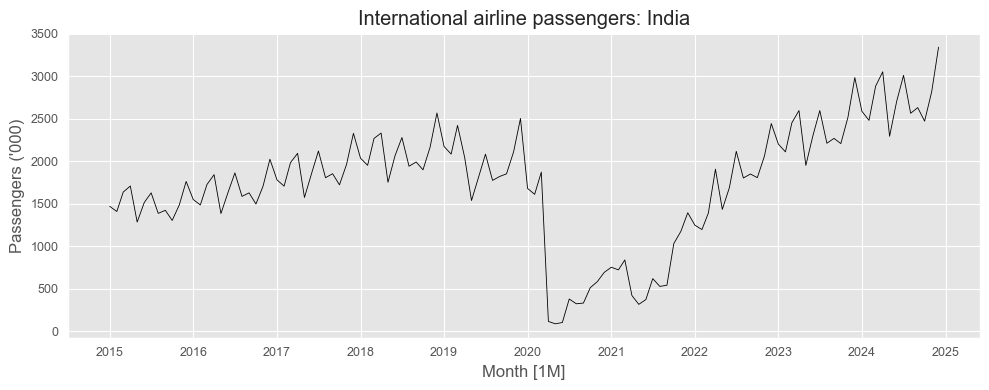

In [22]:
########################################################## Fig 2.1 ##################################################

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")
file_path = data_dir / "india_month_intl_passengers_2015_2024.csv"

df = pd.read_csv(file_path)

df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

plt.style.use("ggplot")
plt.figure(figsize=(10, 4))

plt.plot(
    df["ds"],
    df["intl_passengers"],
    color="black", linewidth=0.6,
    solid_capstyle="round",
    solid_joinstyle="round"
)

# ---- Ansett-style axis formatting ----
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("International airline passengers: India")
plt.xlabel("Month [1M]")
plt.ylabel("Passengers ('000)")

plt.tight_layout()
plt.savefig(fig_dir / "fig_02_01.png", dpi=300, bbox_inches="tight")
plt.show()


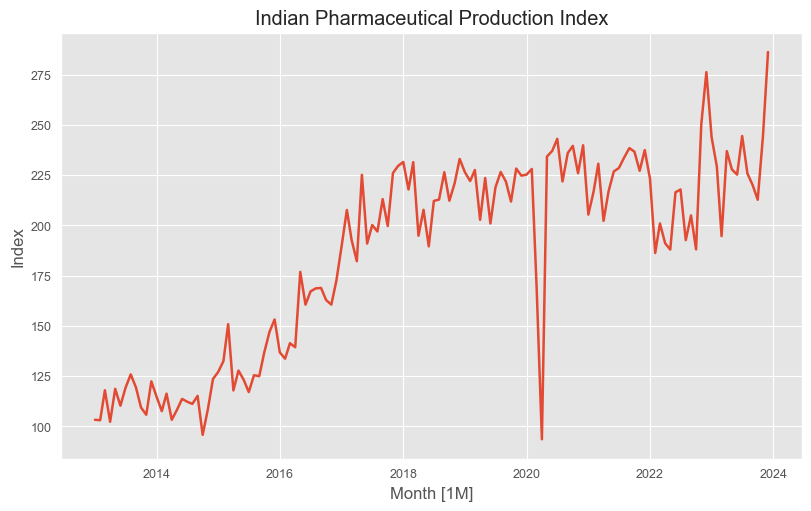

In [28]:
########################################################## Fig 2.2 ##################################################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path =  data_dir / "india_month_pharma_prod_index_2013-2023.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])

# ------------------------------------------------------------
# 3. PLOT 
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["ds"], df["pharma_prod_index"], linewidth=1.8)

plt.xlabel("Month [1M]")
plt.ylabel("Index")
plt.title("Indian Pharmaceutical Production Index")

plt.grid(True)
plt.savefig(fig_dir / "fig_02_02.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_14092/3933407348.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


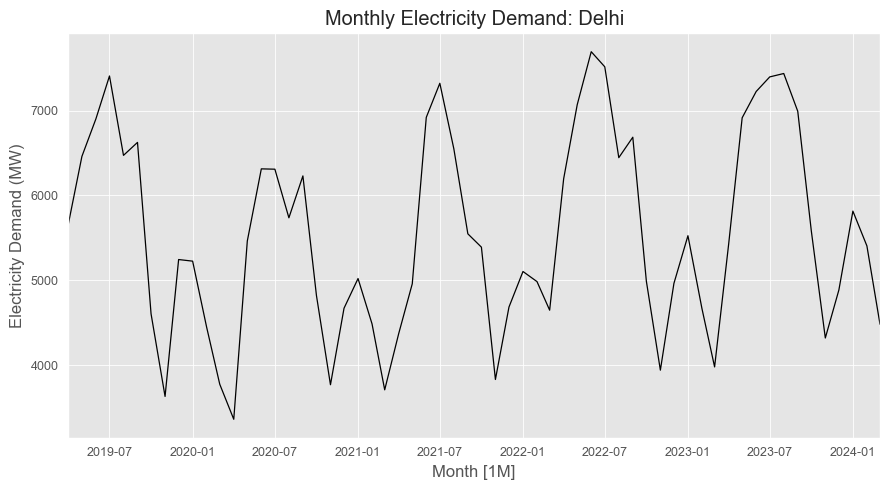

In [32]:
########################################################## Fig 2. 12##################################################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = data_dir /  "delhi_monthly_electricity_demand_2020_2024.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# ------------------------------------------------------------
# 3. PLOT (BOOK STYLE)
# ------------------------------------------------------------
plt.style.use("ggplot")   # <-- FPP-style background

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    df["ds"],
    df["electricity_demand"],
    color="black",
    linewidth=0.9
)

ax.set_xlabel("Month [1M]")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_title("Monthly Electricity Demand: Delhi")

ax.margins(x=0)
ax.grid(True, which="major", linewidth=0.6)

plt.tight_layout()
plt.savefig(fig_dir / "fig_02_03.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\Anant Singh\AppData\Local\Temp\ipykernel_15568\1379130914.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


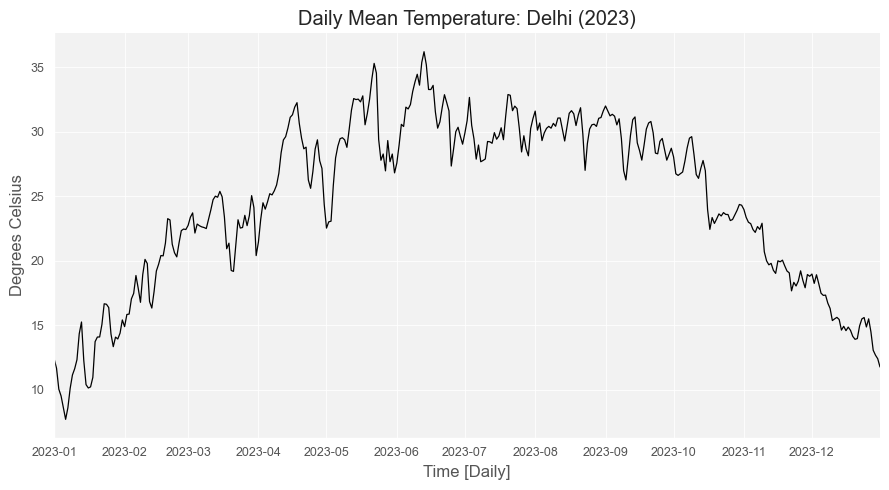

In [7]:
########################################################## Fig 2.13 ##################################################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = r"E:/Forecasting Principles_Practice/Compiled Data/ERA5_Delhi_Daily_Mean_Temperature_2023.csv"
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA 
# ------------------------------------------------------------
df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True)
df = df.sort_values("date")

# Equivalent to max_insample_length in plot_series
max_insample_length = 365
df = df.tail(max_insample_length)

# ------------------------------------------------------------
# 3. PLOT 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    df["date"],
    df["tmean_celsius"],
    color="black",
    linewidth=0.9
)

ax.set_xlabel("Time [Daily]")
ax.set_ylabel("Degrees Celsius")
ax.set_title("Daily Mean Temperature: Delhi (2023)")

# plot_series-style background
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")

ax.grid(
    True,
    which="major",
    axis="both",
    linestyle="-",
    linewidth=0.6,
    color="white"
)

ax.margins(x=0)

# Clean spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
########################################################## Fig 2.14 ##################################################

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# ELECTRICITY (MONTHLY)
# ------------------------------------------------------------
elec_path = r"E:/Forecasting Principles_Practice/Compiled Data/delhi_monthly_electricity_demand_2020_2024.xlsx"
elec = pd.read_excel(elec_path)

elec["ds"] = pd.to_datetime(elec["ds"])
elec = elec.sort_values("ds")

elec = elec.rename(columns={"electricity_demand": "Demand"})


In [10]:
# ------------------------------------------------------------
# TEMPERATURE (DAILY → MONTHLY)
# ------------------------------------------------------------
temp_path = r"E:/Forecasting Principles_Practice/Compiled Data/ERA5_Delhi_Daily_Mean_Temperature_2023.csv"
temp = pd.read_csv(temp_path)

temp["date"] = pd.to_datetime(temp["date"], format="mixed", dayfirst=True)

# Convert to monthly mean (BOOK-CORRECT STEP)
temp["month"] = temp["date"].dt.to_period("M").dt.to_timestamp()

temp_monthly = (
    temp
    .groupby("month", as_index=False)
    .agg(Temperature=("tmean_celsius", "mean"))
)


In [11]:
# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------
df = elec.merge(
    temp_monthly,
    left_on="ds",
    right_on="month",
    how="inner"
)


C:\Users\Anant Singh\AppData\Local\Temp\ipykernel_15568\869271478.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


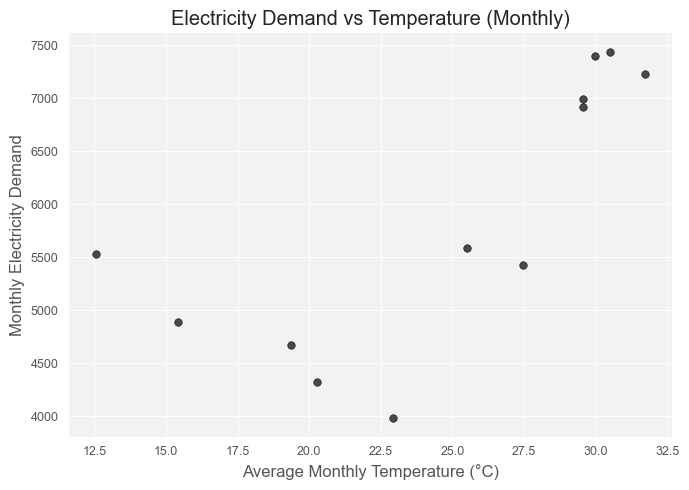

In [12]:
# ------------------------------------------------------------
# SCATTER PLOT 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df["Temperature"],
    df["Demand"],
    color="black",
    alpha=0.7,
    s=30
)

ax.set_title("Electricity Demand vs Temperature (Monthly)")
ax.set_xlabel("Average Monthly Temperature (°C)")
ax.set_ylabel("Monthly Electricity Demand")

# Book-style aesthetics
ax.set_facecolor("#f2f2f2")
ax.grid(True, color="white", linewidth=0.6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [13]:
## For Fig 2.12 to 2.14. we can use this also. This is daily AQI vs daily temp. AQI data is for period 2022-2024. Temp. data is for period 2023. 
## Another version of the graphs with better scatter plot. 

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_14092/786642883.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


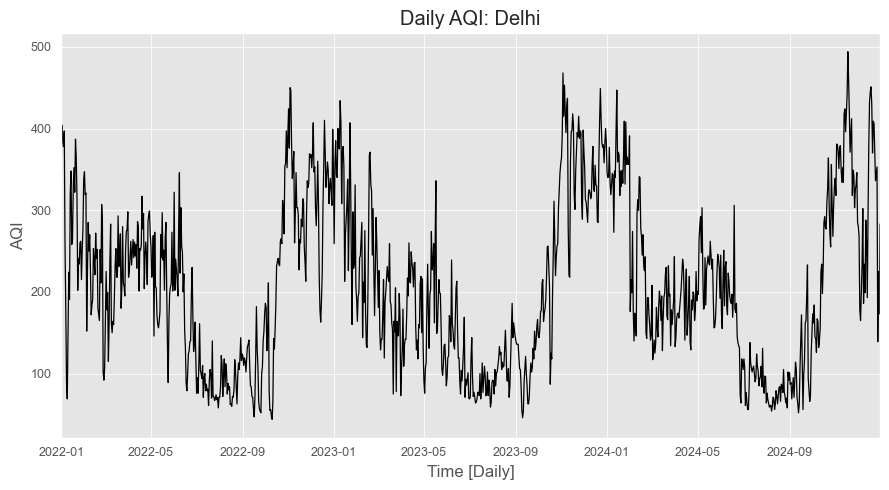

In [34]:
########################################################## Fig 2. 12##################################################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = data_dir /   "india_daily_pollution_2022_2024.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# ------------------------------------------------------------
# 3. PLOT 
# ------------------------------------------------------------
plt.style.use("ggplot")   # <-- FPP-style background

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    df["ds"],
    df["daily_aqi"],
    color="black",
    linewidth=0.9
)

ax.set_xlabel("Time [Daily]")
ax.set_ylabel("AQI")
ax.set_title("Daily AQI: Delhi")

ax.margins(x=0)
ax.grid(True, which="major", linewidth=0.6)

plt.tight_layout()
plt.savefig(fig_dir / "fig_02_12.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_14092/2361206028.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


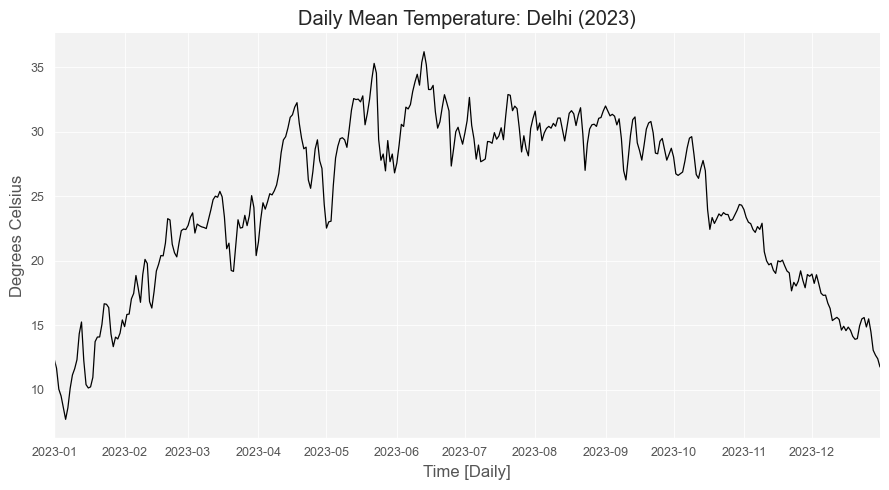

In [36]:
########################################################## Fig 2.13 ##################################################

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = data_dir /  "ERA5_Delhi_Daily_Mean_Temperature_2023.csv"
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA 
# ------------------------------------------------------------
df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True)
df = df.sort_values("date")

# Equivalent to max_insample_length in plot_series
max_insample_length = 365
df = df.tail(max_insample_length)

# ------------------------------------------------------------
# 3. PLOT 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    df["date"],
    df["tmean_celsius"],
    color="black",
    linewidth=0.9
)

ax.set_xlabel("Time [Daily]")
ax.set_ylabel("Degrees Celsius")
ax.set_title("Daily Mean Temperature: Delhi (2023)")

# plot_series-style background
ax.set_facecolor("#f2f2f2")
fig.patch.set_facecolor("white")

ax.grid(
    True,
    which="major",
    axis="both",
    linestyle="-",
    linewidth=0.6,
    color="white"
)

ax.margins(x=0)

# Clean spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "fig_02_13.png", dpi=300, bbox_inches="tight")
plt.show()


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# AQI (DAILY)
# ------------------------------------------------------------
aqi_path = data_dir /   "india_daily_pollution_2022_2024.xlsx"
aqi = pd.read_excel(aqi_path)

aqi["ds"] = pd.to_datetime(aqi["ds"])
aqi = aqi.sort_values("ds")

# Keep only 2023
aqi_2023 = aqi.query("ds.dt.year == 2023")

aqi_2023 = aqi_2023.rename(columns={"daily_aqi": "AQI"})


In [42]:
# ------------------------------------------------------------
# TEMPERATURE (DAILY)
# ------------------------------------------------------------
temp_path = data_dir /  "ERA5_Delhi_Daily_Mean_Temperature_2023.csv"
temp = pd.read_csv(temp_path)

temp["date"] = pd.to_datetime(temp["date"], format="mixed", dayfirst=True)
temp = temp.sort_values("date")

temp = temp.rename(columns={"tmean_celsius": "Temperature"})


In [44]:
# ------------------------------------------------------------
# MERGE (DAILY)
# ------------------------------------------------------------
df = aqi_2023.merge(
    temp,
    left_on="ds",
    right_on="date",
    how="inner"
)


Rows in AQI: 365
Rows in Temp: 365
Rows in Merged DF: 365


/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_14092/3558111047.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


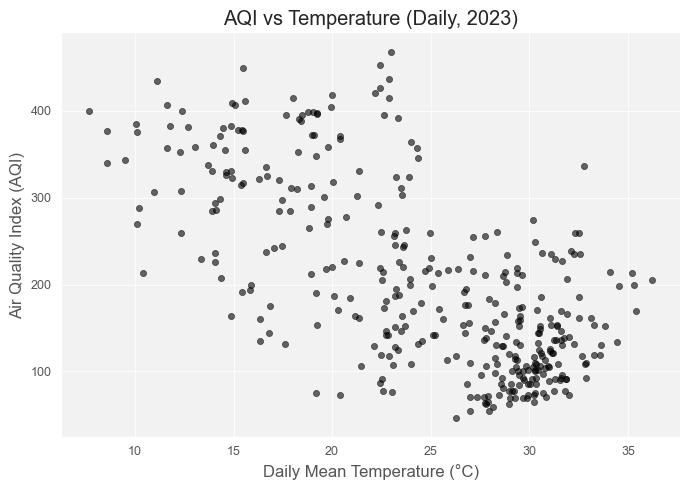

In [46]:
# ------------------------------------------------------------
# SCATTER PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
print(f"Rows in AQI: {len(aqi_2023)}")
print(f"Rows in Temp: {len(temp)}")
print(f"Rows in Merged DF: {len(df)}")
ax.scatter(
    df["Temperature"],
    df["AQI"],
    color="black",
    alpha=0.6,
    s=20
)

ax.set_title("AQI vs Temperature (Daily, 2023)")
ax.set_xlabel("Daily Mean Temperature (°C)")
ax.set_ylabel("Air Quality Index (AQI)")

# Book-style aesthetics
ax.set_facecolor("#f2f2f2")
ax.grid(True, color="white", linewidth=0.6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "fig_02_14.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\Anant Singh\AppData\Local\Temp\ipykernel_15568\794772854.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.88, 1])


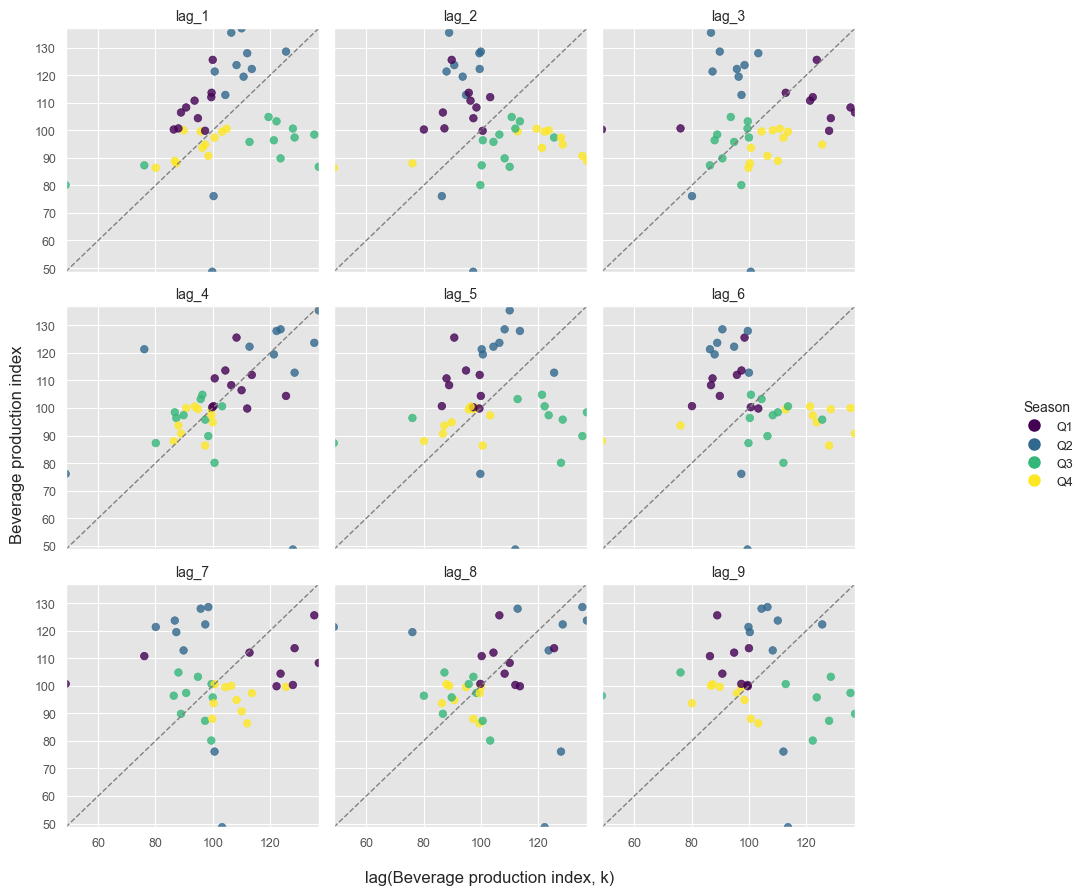

In [20]:
################################################### Fig. 2.19 #######################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = r"E:/Forecasting Principles_Practice/Compiled Data/india_quart_bevg_prod_index_2013_2023.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# Rename to match book notation
df = df.rename(columns={"beverage_prod_index": "y"})

# Quarter as seasonal indicator
df["Quarter"] = df["ds"].dt.quarter

# ------------------------------------------------------------
# 3. CREATE LAGS (1–9)
# ------------------------------------------------------------
for lag in range(1, 10):
    df[f"lag_{lag}"] = df["y"].shift(lag)

lags = [f"lag_{i}" for i in range(1, 10)]

# Axis limits (shared across panels)
lims = [
    np.nanmin([df[lag].min() for lag in lags] + [df["y"].min()]),
    np.nanmax([df[lag].max() for lag in lags] + [df["y"].max()])
]

# ------------------------------------------------------------
# 4. LAG SCATTER PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharex=True, sharey=True)

for ax, lag in zip(axes.flatten(), lags):
    ax.scatter(
        df[lag],
        df["y"],
        c=df["Quarter"],
        cmap="viridis",
        alpha=0.8,
        s=30
    )
    ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{lag}", fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

# ------------------------------------------------------------
# 5. LEGEND (SEASON / QUARTER)
# ------------------------------------------------------------
unique_quarters = sorted(df["Quarter"].dropna().unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_quarters)))

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, markersize=8)
    for color in colors
]
labels = [f"Q{q}" for q in unique_quarters]

fig.legend(
    handles,
    labels,
    title="Season",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# ------------------------------------------------------------
# 6. COMMON LABELS
# ------------------------------------------------------------
fig.supxlabel("lag(Beverage production index, k)")
fig.supylabel("Beverage production index")

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


C:\Users\Anant Singh\AppData\Local\Temp\ipykernel_15568\2665239246.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


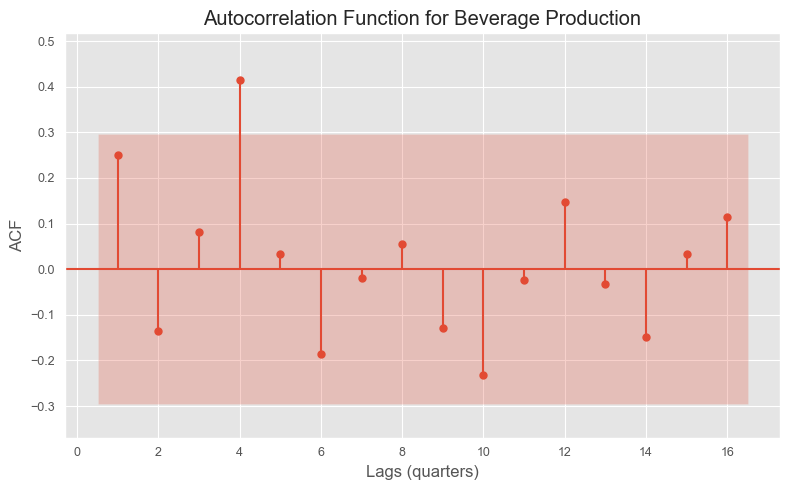

In [21]:
################################################### Fig. 2.20 #######################################################
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = r"E:/Forecasting Principles_Practice/Compiled Data/india_quart_bevg_prod_index_2013_2023.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# Rename to book-style notation
df = df.rename(columns={"beverage_prod_index": "y"})

# ------------------------------------------------------------
# 3. ACF PLOT 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    df["y"],
    lags=16,                  # quarterly data → 4 years
    ax=ax,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True
)

ax.set_title("Autocorrelation Function for Beverage Production")
ax.set_xlabel("Lags (quarters)")
ax.set_ylabel("ACF")

plt.tight_layout()
plt.show()


C:\Users\Anant Singh\AppData\Local\Temp\ipykernel_15568\1672402383.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


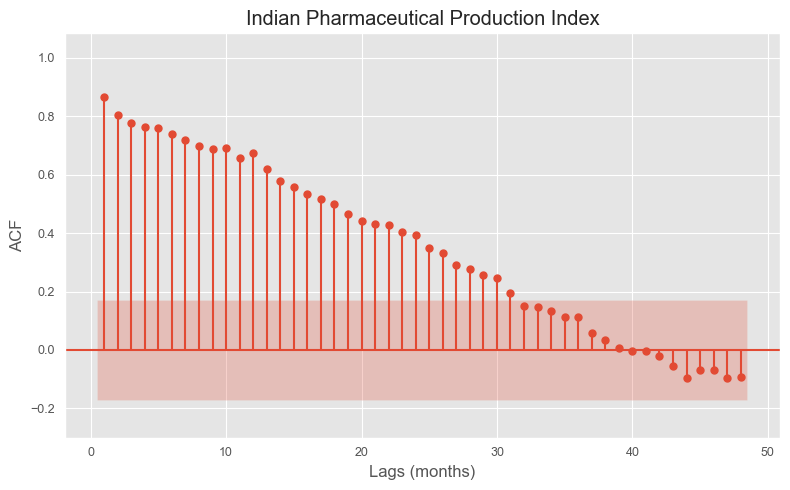

In [22]:
################################################### Fig. 2.21 #######################################################

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
file_path = r"E:/Forecasting Principles_Practice/Compiled Data/india_month_pharma_prod_index_2013-2023.xlsx"
df = pd.read_excel(file_path)

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values("ds")

# Rename to book-style variable
df = df.rename(columns={"pharma_prod_index": "y"})

# ------------------------------------------------------------
# 3. ACF PLOT 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

plot_acf(
    df["y"],
    lags=48,                 # monthly data → 4 years
    ax=ax,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True
)

ax.set_title("Indian Pharmaceutical Production Index")
ax.set_xlabel("Lags (months)")
ax.set_ylabel("ACF")

# Match book-style lower bound
ax.set_ylim(bottom=-0.3)

plt.tight_layout()
plt.show()

